In [ ]:
from sklearn import linear_model
import sys
from sklearn import linear_model
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import pyreadr 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f
from scipy.stats import chi2
import math
from scipy.stats import gmean
import re

In [202]:
df = pd.read_json('data_prepared/regression_data_combined')
df.columns

Index(['price', 'country', 'km', 'age', 'transmission', 'fuel'], dtype='object')

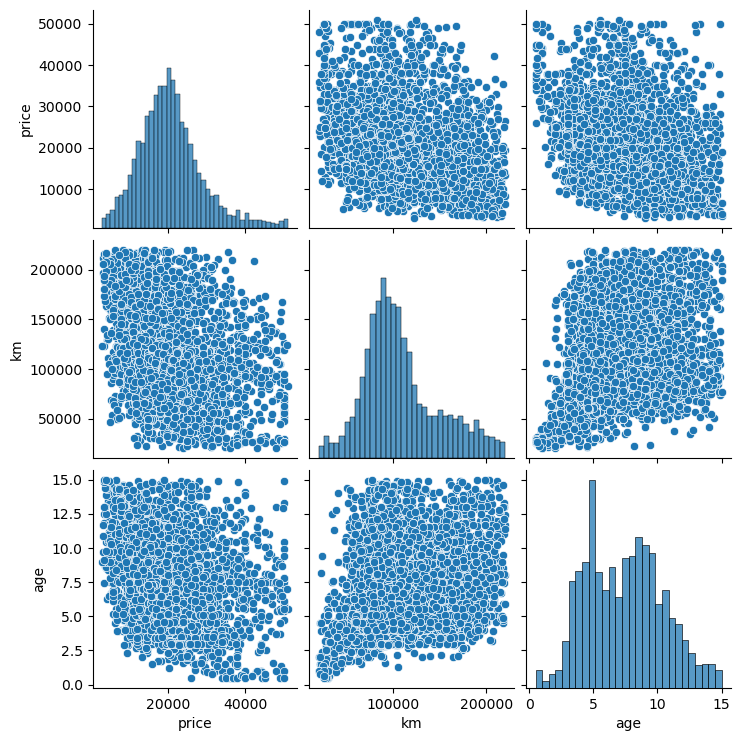

In [203]:
sns.pairplot(df[['price', 'km', 'age', 'transmission', 'fuel']])
plt.show()

In [241]:
# correlation are not that clean, lets try logs (km, price)
df['age'] = df['age']

df['log_km'] = np.log(df['km'])
df['log_price'] = np.log(df['price'])
df['log_age'] = np.log(df['age'])

df['c_age'] = df['age'] - df['age'].mean()
df['c_log_km'] = df['log_km'] - df['log_km'].mean()


df

,price,country,km,age,transmission,fuel,log_km,log_price,log_age,c_age,...,c_log_km__isManual,isElectric,isPluginHybrid,isHybrid,isDiesel,age__isElectric,log_km__isElectric,is_NL,c_age__NL,c_log_km__NL
0,20250.0,NL,99953,9.5,Automatic,Petrol,11.512455,9.915910,2.251292,2.079741,...,-0.0,0,0,0,0,0.0,0.000000,1,2.079741,-0.015438
1,23900.0,NL,95614,9.5,Automatic,Petrol,11.468075,10.081634,2.251292,2.079741,...,-0.0,0,0,0,0,0.0,0.000000,1,2.079741,-0.059819
2,17995.0,NL,117206,10.5,Automatic,Petrol,11.671688,9.797849,2.351375,3.079741,...,0.0,0,0,0,0,0.0,0.000000,1,3.079741,0.143795
3,21950.0,NL,122495,11.8,Automatic,Petrol,11.715825,9.996522,2.468100,4.379741,...,0.0,0,0,0,0,0.0,0.000000,1,4.379741,0.187932
4,27900.0,NL,86000,8.6,Automatic,Petrol,11.362103,10.236382,2.151762,1.179741,...,-0.0,0,0,0,0,0.0,0.000000,1,1.179741,-0.165791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4857,22870.0,GER,95100,2.9,Automatic,Electric,11.462684,10.037581,1.064711,-4.520259,...,-0.0,1,0,0,0,2.9,11.462684,0,-0.000000,-0.000000
4858,14890.0,GER,49983,7.3,Automatic,Electric,10.819438,9.608445,1.987874,-0.120259,...,-0.0,1,0,0,0,7.3,10.819438,0,-0.000000,-0.000000
4859,14950.0,GER,49971,7.3,Automatic,Electric,10.819198,9.612467,1.987874,-0.120259,...,-0.0,1,0,0,0,7.3,10.819198,0,-0.000000,-0.000000
4860,17890.0,GER,72300,4.0,Automatic,Electric,11.188579,9.791997,1.386294,-3.420259,...,-0.0,1,0,0,0,4.0,11.188579,0,-0.000000,-0.000000


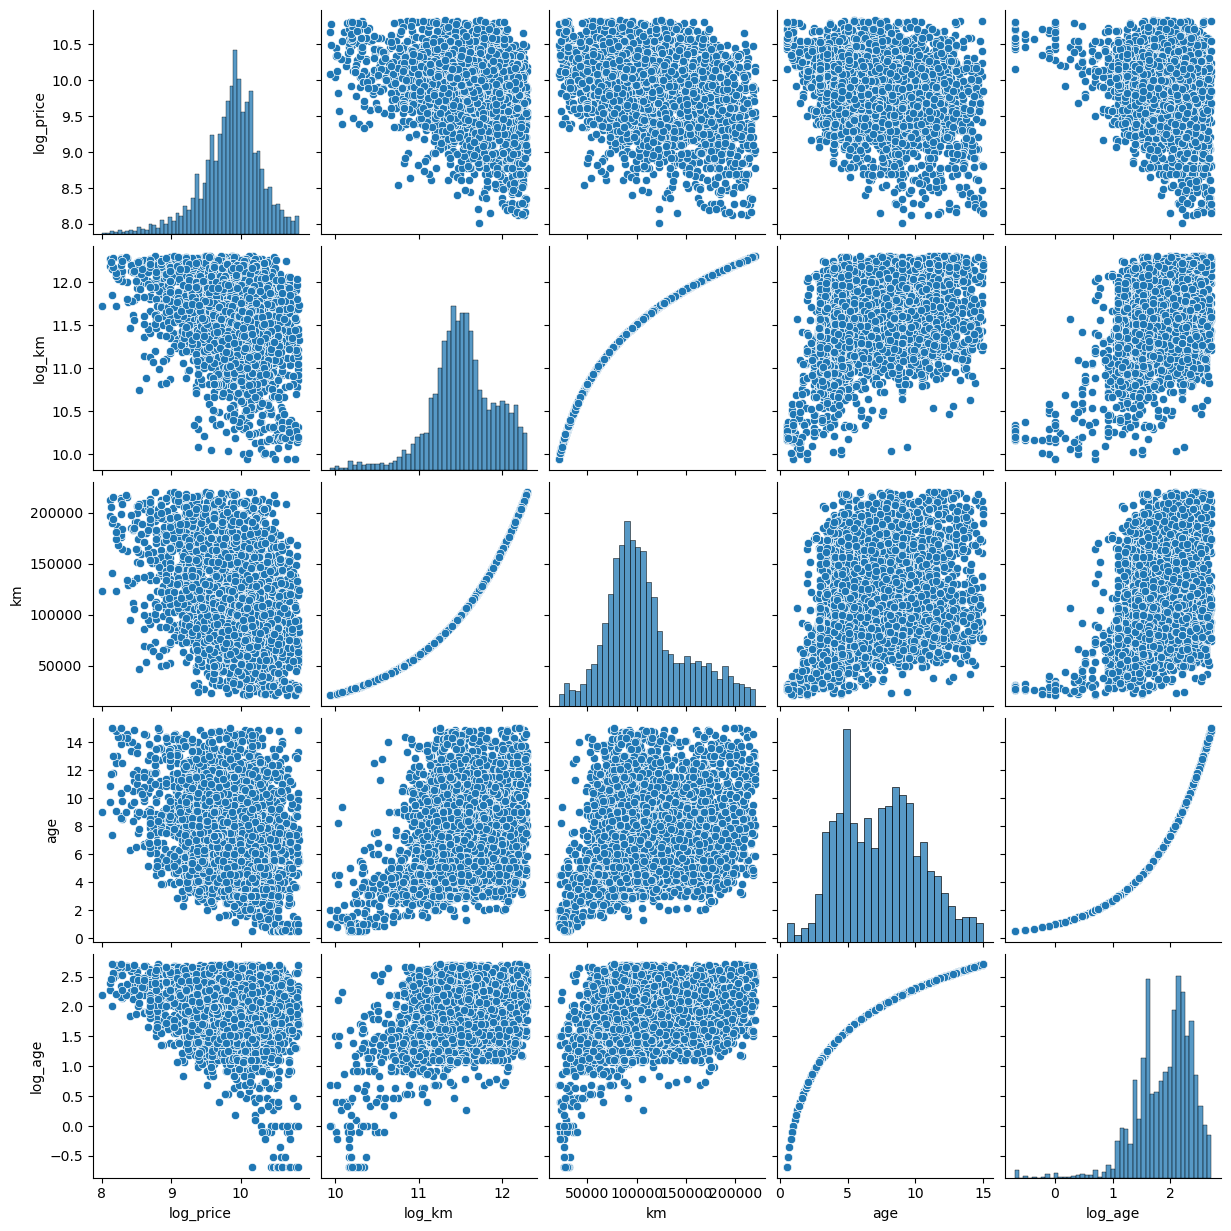

In [247]:
# correlation improved

sns.pairplot(df[['log_price', 'country', 'log_km','km', 'age','log_age', 'transmission', 'fuel']])
plt.show()

In [248]:
df[['price','log_price', 'km','log_km','age','log_age']].corr()

,price,log_price,km,log_km,age,log_age
price,1.000000,0.948615,-0.292918,-0.302733,-0.269200,-0.294487
log_price,0.948615,1.000000,-0.349405,-0.337612,-0.294815,-0.299227
km,-0.292918,-0.349405,1.000000,0.960243,0.200747,0.247097
log_km,-0.302733,-0.337612,0.960243,1.000000,0.254589,0.338302
age,-0.269200,-0.294815,0.200747,0.254589,1.000000,0.943862
log_age,-0.294487,-0.299227,0.247097,0.338302,0.943862,1.000000


price has stronger correlation with 'log_km' than 'km', also 'log_age' has a stronger correlation than 'age'</br>



Colinearity:
km - age: visible pattern at low values, disperses quickly
log_km - log_age: weaker pattern

colinearity is present

# simple models

#### regression 1: Lin-Lin
$price = \beta_1 +\beta_2{age} + \beta_3{km}$

In [208]:
X = df[['age','km']]
y = df[['price']]

model = sm.OLS(y, sm.add_constant(X)).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     369.2
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          5.28e-150
Time:                        03:20:18   Log-Likelihood:                -50364.
No. Observations:                4862   AIC:                         1.007e+05
Df Residuals:                    4859   BIC:                         1.008e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.076e+04    382.710     80.365      0.0

#### Regression 2: Linear PLS

In [209]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['age','km']]
y = df[['price']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))


pls = PLSRegression(n_components=2)
pls.fit(X_train_scaled, y_train_scaled)


import statsmodels.api as sm

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     369.2
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          5.28e-150
Time:                        03:20:18   Log-Likelihood:                -50364.
No. Observations:                4862   AIC:                         1.007e+05
Df Residuals:                    4859   BIC:                         1.008e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.076e+04    382.710     80.365      0.0

#### REG1 vs REG2: OLS vs PLS
##### almost identical coeficients, statistical significance, r2 …

#### Regression 3: Log-Log
$$ln(price) = \beta_1 +\beta_2ln({age}) + \beta_3ln({km})$$

In [210]:
X = df[['log_age','log_km']]
y = df[['log_price']]

model = sm.OLS(y, sm.add_constant(X)).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     437.6
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          1.77e-175
Time:                        03:20:18   Log-Likelihood:                -2321.9
No. Observations:                4862   AIC:                             4650.
Df Residuals:                    4859   BIC:                             4669.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.5440      0.169     80.366      0.0

#### Regression 4: Mixed model
$\textcolor{lightgreen}{ln(price)_i = \beta_1 +\beta_2{age}_i + \beta_3ln({km})_i + \epsilon_i}$

In [211]:
X = df[['age','log_km']]
y = df[['log_price']]

model = sm.OLS(y, sm.add_constant(X)).fit()

print(model.summary())

summary_table = pd.DataFrame({
    'coef': round(model.params,3),
    'std_err': round(model.bse,3),
    'p_value': round(model.pvalues,3)
})

print(summary_table)

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     464.9
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          1.76e-185
Time:                        03:20:18   Log-Likelihood:                -2298.9
No. Observations:                4862   AIC:                             4604.
Df Residuals:                    4859   BIC:                             4623.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.5982      0.166     81.672      0.0

# Models with transmission

### generate is_manual

In [251]:
def transmission_type(x):
    if x == 'Automatic':
        return 0
    else:
        return 1

df['is_manual'] = df['transmission'].apply(lambda x: transmission_type(x))


### Generate other variables

In [253]:
# age * is_manual

df['c_age__isManual'] = df['c_age'] * df['is_manual']


# log_km * is_manual

df['c_log_km__isManual'] = df['c_log_km'] * df['is_manual']

### Generate variables

In [256]:
# PETROL IS BASELINE

# electric
def get_isElectric(x):
    if x == 'Electric':
        return 1
    else:
        return 0
df['isElectric'] = df['fuel'].apply(lambda x: get_isElectric(x))

# plug in hybrid
def get_isPluginHybrid(x):
    if x == 'Plug-in Hybrid':
        return 1
    else:
        return 0
df['isPluginHybrid'] = df['fuel'].apply(lambda x: get_isPluginHybrid(x))

# hybrid
def get_isHybrid(x):
    if x == 'Hybrid':
        return 1
    else:
        return 0
df['isHybrid'] = df['fuel'].apply(lambda x: get_isHybrid(x))

# diesel
def get_isDiesel(x):
    if x == 'Diesel':
        return 1
    else:
        return 0
df['isDiesel'] = df['fuel'].apply(lambda x: get_isDiesel(x))



# age * is_electric

df['age__isElectric'] = df['age'] * df['isElectric']


# log_km * isElectric

df['log_km__isElectric'] = df['log_km'] * df['isElectric']

In [257]:
def get_is_NL(x):
    if x == 'NL':
        return 1
    else:
        return 0
    
df['is_NL'] = df['country'].apply(lambda x: get_is_NL(x))

In [258]:
# age * is_electric

df['c_age__NL'] = df['c_age'] * df['is_NL']


# log_km * isElectric

df['c_log_km__NL'] = df['c_log_km'] * df['is_NL']

In [259]:
X = df[['is_manual','c_age','c_age__isManual','c_log_km','isElectric', 'isDiesel','is_NL','c_age__NL','c_log_km__NL']]
y = df[['log_price']]

model = sm.OLS(y, sm.add_constant(X)).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.415
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     382.5
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:21:38   Log-Likelihood:                -1421.0
No. Observations:                4862   AIC:                             2862.
Df Residuals:                    4852   BIC:                             2927.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              10.0203      0.009   11

In [260]:
df.groupby(['country', 'fuel'])[['price','km','age',"log_price", "log_km"]].mean().round(2)

price         km   age  log_price  log_km
country fuel                                                        
GER     Diesel          22084.26  101480.79  8.68       9.97   11.51
        Electric        22172.00   79361.65  4.75       9.98   11.25
        Hybrid          23184.60   87869.62  5.98      10.03   11.36
        Petrol          19557.39   93661.71  9.17       9.85   11.43
        Plug-in Hybrid  23085.57   87575.71  5.61      10.03   11.35
NL      Diesel          20028.66  140217.72  7.73       9.80   11.80
        Electric        21130.80   99174.42  5.24       9.93   11.48
        Hybrid          24223.23  106875.26  5.36      10.05   11.50
        Petrol          20206.01  129694.08  7.04       9.75   11.66
        Plug-in Hybrid  24390.33  117057.43  4.94      10.06   11.60

In [261]:
df.groupby('country')[['price','km','age',"log_price", "log_km"]].mean()

,price,km,age,log_price,log_km
country,,,,,
GER,20631.204998,92353.427694,8.203728,9.900858,11.409942
NL,20952.729405,125966.306898,6.630318,9.818951,11.646820


In [ ]:
df[['price','age']].corr()

,price,age
price,1.0000,-0.2692
age,-0.2692,1.0000


In [264]:
df[['price','km']].corr()

,price,km
price,1.000000,-0.292918
km,-0.292918,1.000000
